In [736]:
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.dummy import DummyRegressor

import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)  # Viser hele tabellen for enklere visning

pd.set_option('display.max_columns', None)  # Viser alle kolonner i tabellen

# Datatilbredning

## Dempgraphic

In [737]:
#lese inn data fra demographic
df_demographic = pd.read_csv("raw_data/demographic.csv")

Mapper income slik at det det numeriske verider

In [738]:
income_mapping = {
    '$11-$25k': 1,
    'under $11k': 0,
    '$25k-$50k': 2,
    '$50k-$75k': 3,
    'above $75k': 4
}

df_demographic['inntekt'] = df_demographic['inntekt'].map(income_mapping)

## Hospital

In [739]:
df_hospital = pd.read_csv("raw_data/hospital.csv")

Fjerner negativ oppholdslengde, da målet er å predikere oppholdslengde.

In [740]:
df_hospital = df_hospital[df_hospital['oppholdslengde'] >= 0]

## physiological

In [741]:
df_physiological = pd.read_csv("raw_data/physiological.txt", delimiter='\t')

## Severity

In [742]:
df_severity = pd.read_json("raw_data/severity.json")

Koden strukturerer df_severity slik at hver pasient får sine data på separate rader og sorteres etter pasient_id

In [743]:
df_severity = df_severity.iloc[:, 0:-1].explode(list(df_severity.columns[2:-1]))
df_severity.reset_index(drop=True, inplace=True)
df_severity=df_severity.sort_values(by=['pasient_id'], ignore_index=True)

In [744]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohe_transformed_seveity = ohe.fit_transform(df_severity[['sykdomskategori_id','sykdomskategori', 'sykdom_underkategori', 'kreft', 'dnr_status']], )
df_severity = pd.concat([df_severity, ohe_transformed_seveity], axis=1).drop(columns = ['sykdomskategori_id','sykdomskategori', 'sykdom_underkategori', 'kreft', 'dnr_status'])

ohe_transformed_demographic = ohe.fit_transform(df_demographic[['kjønn', 'etnisitet']])
df_demographic = pd.concat([df_demographic, ohe_transformed_demographic], axis=1).drop(columns = ['kjønn', 'etnisitet'])

df_severity.head()

,pasient_id,dødsfall,antall_komorbiditeter,koma_score,adl_pasient,adl_stedfortreder,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdomskategori_id_A1s,sykdomskategori_id_BrY,sykdomskategori_id_ChE,sykdomskategori_id_DWw,sykdomskategori_ARF/MOSF,sykdomskategori_COPD/CHF/Cirrhosis,sykdomskategori_Cancer,sykdomskategori_Coma,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,dnr_status_dnr før innleggelse,dnr_status_dnr ved innleggelse,dnr_status_None
0,2,1,2,44.0,None,1.0,52.695312,74.0,0.001,0.0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,3,1,2,0.0,1.0,0.0,20.5,45.0,0.790894,0.664917,0,0,0.75,0.5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,4,1,2,0.0,0.0,0.0,20.097656,19.0,0.698975,0.411987,0,0,0.9,0.5,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,5,0,1,26.0,None,2.0,23.5,30.0,0.634888,0.532959,0,0,0.9,0.9,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,6,1,1,55.0,None,1.0,19.398438,27.0,0.284973,0.214996,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## Merger datasett

In [745]:
# Slå sammen df_severity og df_demographic basert på pasient_id
df = pd.merge(df_severity, df_demographic, on='pasient_id', how='inner')

# Slå sammen resultatet med df_hospital
df = pd.merge(df, df_hospital, on='pasient_id', how='inner')

# Slå sammen resultatet med df_physiological
df = pd.merge(df, df_physiological, on='pasient_id', how='inner')

df = df.astype(float)


## Fjerner duplikater

In [746]:
# Tell og fjern duplikater
antall_duplikater = df.duplicated().sum()
df = df.drop_duplicates()

# Tell og fjern rader med negativ alder
negativ_alder_count = (df['alder'] < 0).sum()
print("Antall pasienter med negativ alder i df_merged:", negativ_alder_count)
df = df[df['alder'] >= 0]

# Fjern spesifikke sykdomskategorier
df = df.drop([
    'sykdomskategori_id_A1s', 'sykdomskategori_id_BrY', 'sykdomskategori_id_ChE',
    'sykdomskategori_id_DWw', 'sykdomskategori_ARF/MOSF', 'sykdomskategori_COPD/CHF/Cirrhosis',
    'sykdomskategori_Cancer', 'sykdomskategori_Coma'
], axis=1)

Antall duplikater i df_merged: 2
Antall pasienter med negativ alder i df_merged: 5


## NaN-verdier

Setter inn anbefalte verider fra: https://archive.ics.uci.edu/dataset/880/support2

In [747]:
# Imputere manglende verdier 
df['serumalbumin'].fillna(3.5, inplace=True)
df['lungefunksjon'].fillna(333.3, inplace=True)
df['bilirubin'].fillna(1.01, inplace=True)
df['kreatinin'].fillna(1.01, inplace=True)
df['blodurea_nitrogen'].fillna(6.51, inplace=True)
df['hvite_blodlegemer'].fillna(9, inplace=True)
df['urinmengde'].fillna(2502, inplace=True)

/var/folders/1h/__q6rdbs1lqc2l3nlfz9t72m0000gn/T/ipykernel_44655/2626770090.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/var/folders/1h/__q6rdbs1lqc2l3nlfz9t72m0000gn/T/ipykernel_44655/2626770090.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

## Slår sammen adl_pasient og adl_stedfortreder

In [748]:
df['adl'] = df['adl_pasient'].fillna(df['adl_stedfortreder'])
df.drop(['adl_pasient', 'adl_stedfortreder'], axis=1, inplace=True)

## Fjerner DNR status og DNR dag da dette ikke har noe med oppholdlengede å gjøre

In [749]:
df.drop(['dnr_status_dnr før innleggelse','dnr_status_dnr ved innleggelse', 'dnr_status_None'], axis=1, inplace=True)


## Fjerner verdier som er målt på dag 7

In [750]:
df.drop('bilirubin', axis=1, inplace= True)

## Fjerner dødsfall, sykehusdød og pasient_id

In [751]:
df.drop('dødsfall', axis = 1, inplace = True)
df.drop('sykehusdød', axis=1, inplace = True)
df.drop('pasient_id', axis=1, inplace = True)

In [752]:
#df = pd.read_csv("vasket_data.csv")

# Deler opp i treningsdata, testdata og valideringsdata

In [753]:
X = df.drop(columns=['oppholdslengde']) #feature
y = df['oppholdslengde'] #target-sett

#trenings og midlertidig sett
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# deler det midlertidige settet i validering og test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Utforskende dataanalyse

## Statistisk beskrivelse av variablene i datasettet 

In [754]:
X_train.describe()

,antall_komorbiditeter,koma_score,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,alder,utdanning,inntekt,kjønn_female,kjønn_male,etnisitet_asian,etnisitet_black,etnisitet_hispanic,etnisitet_other,etnisitet_white,etnisitet_nan,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde,adl
count,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,4404.000000,4416.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.00000,5410.000000,5410.000000,5410.000000,4433.000000,2598.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,4080.000000,2743.000000,5410.000000,5410.000000,4176.000000
mean,1.840850,12.202957,25.603450,37.809797,0.632434,0.516665,0.191128,0.034935,0.614721,0.497405,0.392237,0.149908,0.104251,0.051756,0.057856,0.066359,0.100555,0.077079,0.20610,0.657486,0.136414,62.815565,11.796752,0.358353,0.434381,0.565619,0.009982,0.154713,0.031423,0.011460,0.787616,0.004806,84.693438,12.340621,97.618983,23.406654,37.138702,263.188839,3.146953,1.766745,137.622921,7.413809,160.639810,20.100706,2361.892564,1.522270
std,1.330555,24.629400,9.867326,20.159033,0.250074,0.254846,0.393226,0.183633,0.300615,0.304774,0.488294,0.357014,0.305615,0.221554,0.233492,0.248931,0.300766,0.266742,0.40454,0.474594,0.343259,15.450071,3.499803,0.479609,0.495721,0.495721,0.099417,0.361665,0.174475,0.106447,0.409033,0.069164,27.808522,9.384883,31.305589,9.554365,1.266966,104.322160,0.699742,1.667329,6.032462,0.081830,88.241442,23.123185,1031.275377,2.138102
min,0.000000,0.000000,1.199951,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,18.146000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31.699220,12.000000,0.399963,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,19.097656,23.000000,0.497986,0.333984,0.000000,0.000000,0.400000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,52.971980,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,64.000000,7.000000,72.000000,18.000000,36.195310,178.000000,2.699707,0.899902,134.000000,7.379883,103.500000,6.510000,2071.250000,0.000000
50%,2.000000,0.000000,24.000000,35.000000,0.711914,0.567993,0.000000,0.000000,0.700000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,65.078490,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,77.000000,10.398438,100.000000,24.000000,36.796880,276.187500,3.500000,1.199951,137.000000,7.419922,134.000000,6.510000,2502.000000,0.000000
75%,3.000000,9.000000,30.199219,49.000000,0.824951,0.724976,0.000000,0.000000,0.900000,0.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,74.042235,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,108.000000,15.174316,120.000000,28.000000,38.195310,333.300000,3.500000,1.899902,141.000000,7.469727,191.000000,25.000000,2502.000000,2.000000
max,8.000000,100.000000,87.500000,143.0

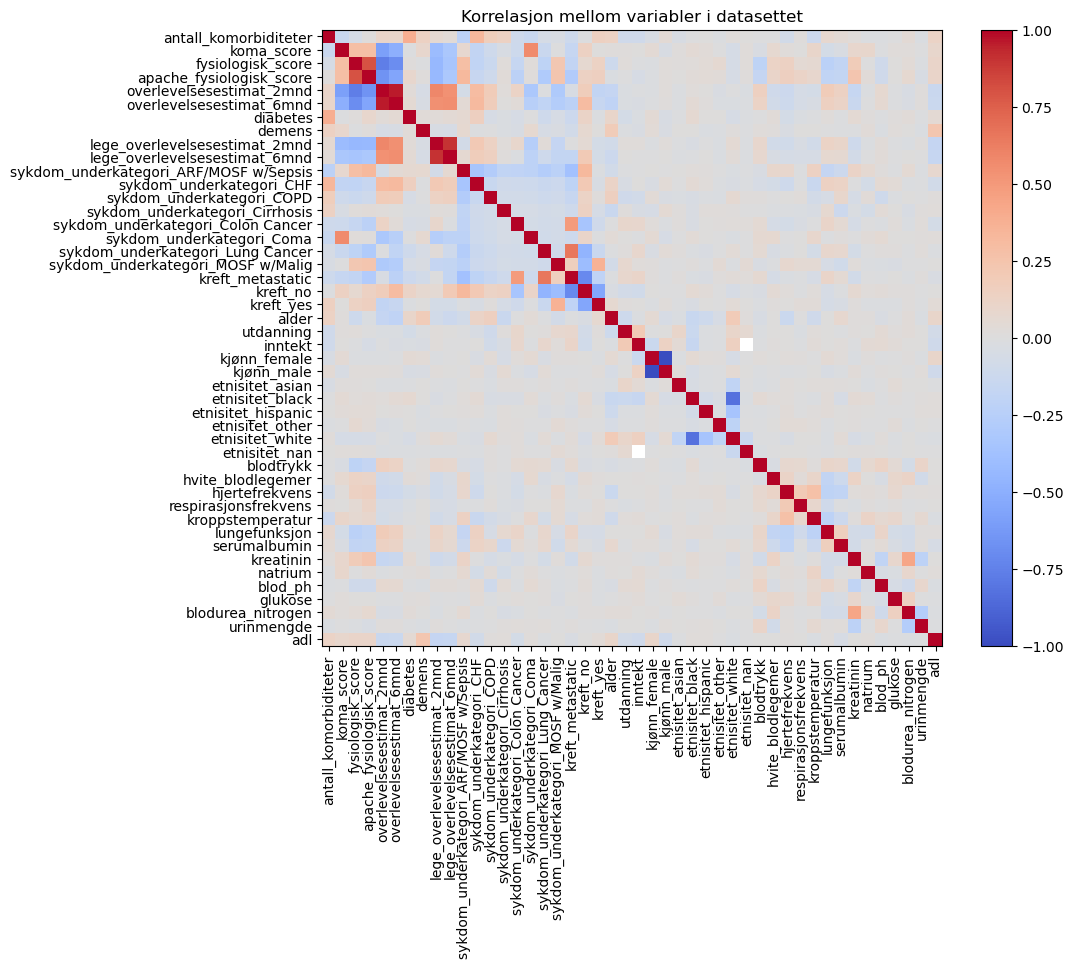

In [755]:
corr_matrix =X_train.corr()

plt.figure(figsize=(10, 8))  
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto') #Heatmap
plt.colorbar() 
plt.title('Korrelasjon mellom variabler i datasettet') 

plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

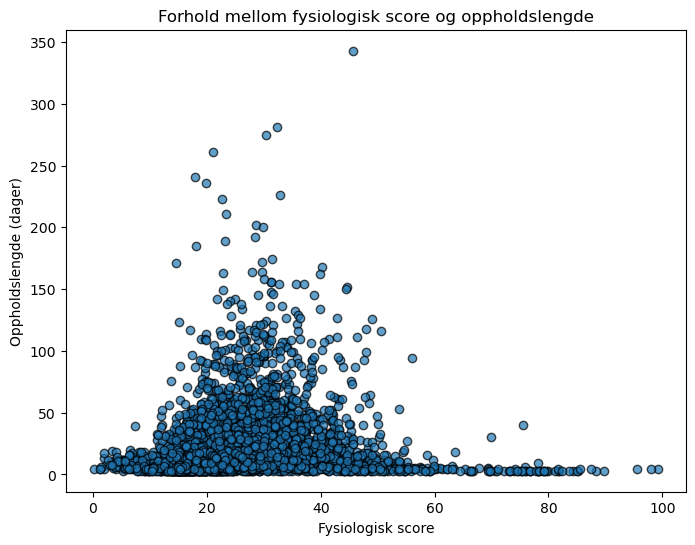

In [756]:
plt.figure(figsize=(8,6))
plt.scatter(df['fysiologisk_score'], df['oppholdslengde'], alpha=0.7, edgecolor='k')
plt.title('Forhold mellom fysiologisk score og oppholdslengde')
plt.xlabel('Fysiologisk score')
plt.ylabel('Oppholdslengde (dager)')
plt.show()

# Datemodellering

## Fjerning av uteliggere

Jeg ser på boksplottet for å vurdere om det er nødvendig å fjerne uteliggere, og for å få en oversikt over hvor mange og hvor ekstreme disse uteliggerne er i datasettet.

Kom til rap: jeg så først overordnet på alle og bestemte meg for de som påvirket modellen mest på en positivt måte. 

In [757]:
def clip_column(dataframe, column_name, lower_quantile=None, upper_quantile=None):
    lower_bound = dataframe[column_name].quantile(lower_quantile) if lower_quantile is not None else None
    upper_bound = dataframe[column_name].quantile(upper_quantile) if upper_quantile is not None else None
    
    dataframe[column_name] = dataframe[column_name].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

### Urinmengde

In [758]:
fig = px.box(X_train['urinmengde'], title = ('Boxplot for urinmengde'))
fig.update_layout(xaxis_title='urinmengde', yaxis_title='Verdi')
fig.show()

Jeg klipper verdiene i urinmengde ved 25. og 75. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [759]:
X_train = clip_column(X_train, "urinmengde", lower_quantile=0.25, upper_quantile=0.75)

### Kreatinin og hvite blodlegemer

In [760]:
fig_kreatinin = px.box(X_train['kreatinin'], title = ('Boxplot for kreatinin'))
fig_kreatinin.update_layout(xaxis_title='kreatinin', yaxis_title='Verdi')
fig_kreatinin.show()

fig_hvite_blodlegemer= px.box(X_train['hvite_blodlegemer'], title = ('Boxplot for hvite blodlegemer'))
fig_hvite_blodlegemer.update_layout(xaxis_title='hvite_blodlegemer', yaxis_title='Verdi')
fig_hvite_blodlegemer.show()

Jeg klipper verdiene i urinmengde ved 95. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [761]:

X_train = clip_column(X_train, "kreatinin", upper_quantile=0.95)
X_train = clip_column(X_train, "hvite_blodlegemer", upper_quantile=0.95)



### Blodurea nitrogen og glukose

In [762]:
fig_blodurea_nitrogen = px.box(X_train['blodurea_nitrogen'], title = ('Boxplot for blodurea nitrogen'))
fig_blodurea_nitrogen.update_layout(xaxis_title='Blodurea nitrogen', yaxis_title='Verdi')
fig_blodurea_nitrogen.show()

fig_glukose= px.box(X_train['glukose'], title = ('Boxplot for glukose'))
fig_glukose.update_layout(xaxis_title='glukose', yaxis_title='Verdi')
fig_glukose.show()

Jeg klipper verdiene i urinmengde ved 75. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [763]:
X_train = clip_column(X_train, "blodurea_nitrogen", upper_quantile=0.75)
X_train = clip_column(X_train, "glukose", upper_quantile=0.75)

### Må gjøre samme operasjoner for X_val og X_test

In [764]:
#X_val

X_val = clip_column(X_val, "urinmengde", lower_quantile=0.25, upper_quantile=0.75)
X_val = clip_column(X_val, "kreatinin", upper_quantile=0.95)
X_val = clip_column(X_val, "hvite_blodlegemer", upper_quantile=0.95)
X_val = clip_column(X_val, "blodurea_nitrogen", upper_quantile=0.75)
X_val = clip_column(X_val, "glukose", upper_quantile=0.75)

#X_test
X_test = clip_column(X_test, "urinmengde", lower_quantile=0.25, upper_quantile=0.75)
X_test = clip_column(X_test, "kreatinin", upper_quantile=0.95)
X_test = clip_column(X_test, "hvite_blodlegemer", upper_quantile=0.95)
X_test = clip_column(X_test, "blodurea_nitrogen", upper_quantile=0.75)
X_test = clip_column(X_test, "glukose", upper_quantile=0.75)


## Feature engineering

Ser først på korrelasjonsmatrise

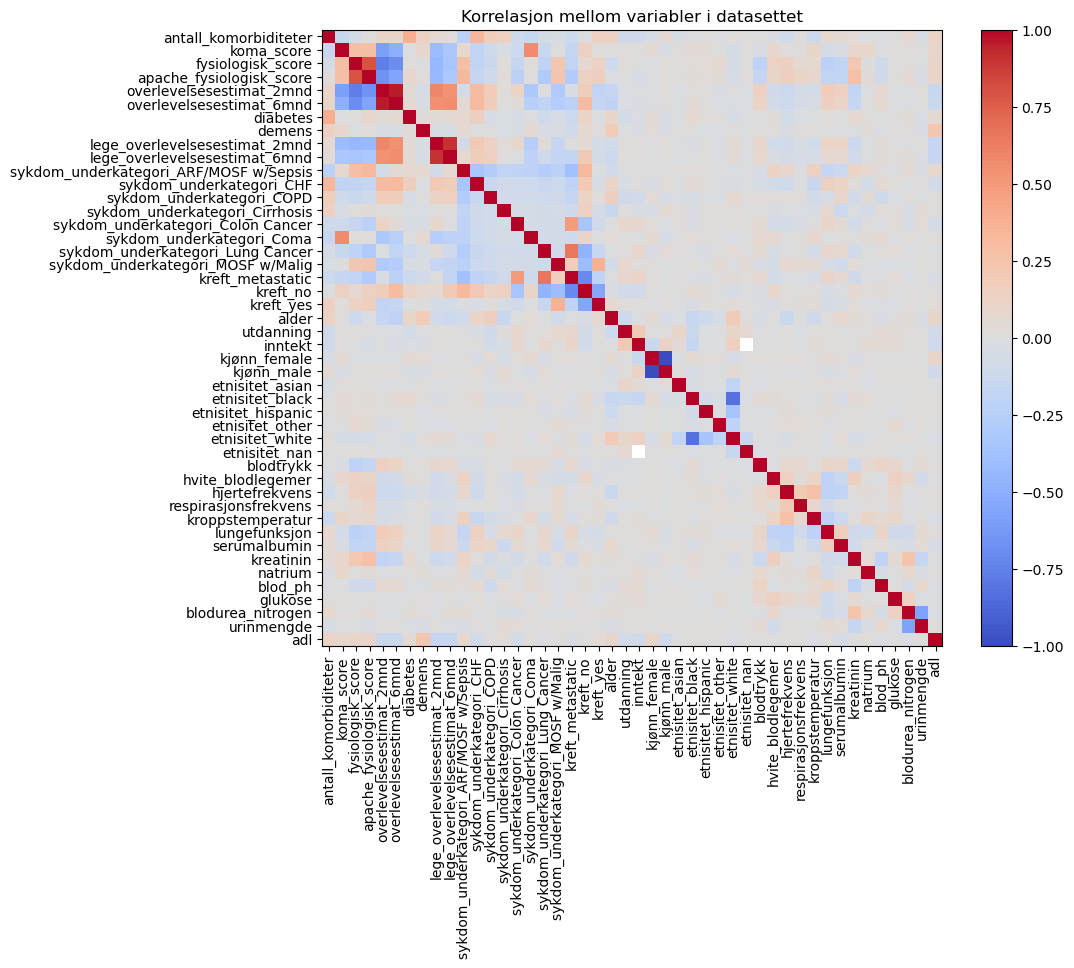

In [765]:
corr_matrix = X_train.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')  # Heatmap
plt.colorbar()
plt.title('Korrelasjon mellom variabler i datasettet')

plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

plt.show() 


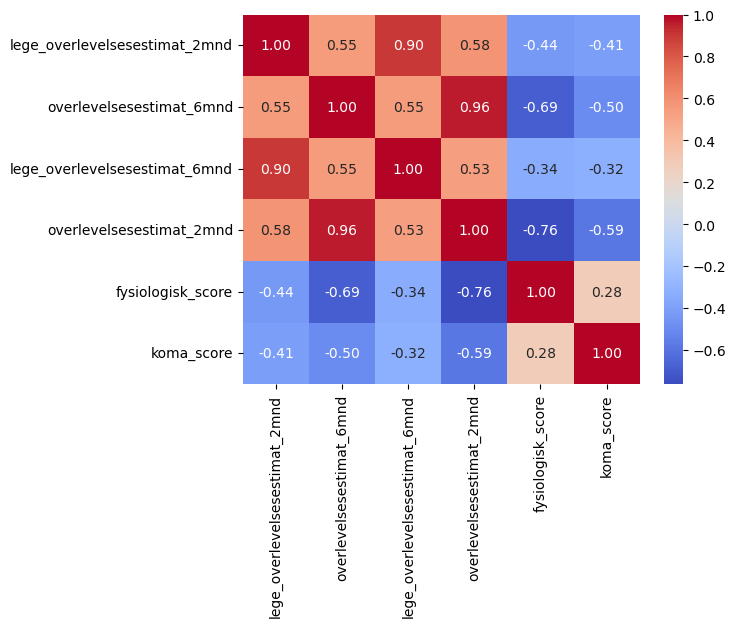

In [766]:
g = sns.heatmap(X_train[["lege_overlevelsesestimat_2mnd", "overlevelsesestimat_6mnd", 
                              "lege_overlevelsesestimat_6mnd", "overlevelsesestimat_2mnd", 
                              "fysiologisk_score", "koma_score"]].corr(),annot=True, fmt = ".2f", cmap = "coolwarm")

Ser at gjennomsnitt overlevelses estimat variablene har mye korrelasjon og det har ogåå koma score og fysiologisk score. Lager dermed en ny korrelasjonmatrise for disse. 

In [767]:
X_train['gjennomsnitt_overlevelsesestimat_estimat_1'] = (X_train['lege_overlevelsesestimat_2mnd'] + X_train['overlevelsesestimat_6mnd']) / 2
X_val['gjennomsnitt_overlevelsesestimat_estimat_1'] = (X_val['lege_overlevelsesestimat_2mnd'] + X_val['overlevelsesestimat_6mnd']) / 2
X_test['gjennomsnitt_overlevelsesestimat_estimat_1'] = (X_test['lege_overlevelsesestimat_2mnd'] + X_test['overlevelsesestimat_6mnd']) / 2


X_train['gjennomsnitt_overlevelsesestimat_estimat_2'] = (X_train['lege_overlevelsesestimat_6mnd'] + X_train['overlevelsesestimat_2mnd']) / 2
X_val['gjennomsnitt_overlevelsesestimat_estimat_2'] = (X_val['lege_overlevelsesestimat_6mnd'] + X_val['overlevelsesestimat_2mnd']) / 2
X_test['gjennomsnitt_overlevelsesestimat_estimat_2'] = (X_test['lege_overlevelsesestimat_6mnd'] + X_test['overlevelsesestimat_2mnd']) / 2


X_train['helsetilstand'] = X_train['fysiologisk_score'] * X_train['koma_score']
X_val['helsetilstand'] = X_val['fysiologisk_score'] * X_val['koma_score']
X_test['helsetilstand'] = X_test['fysiologisk_score'] * X_test['koma_score']




## Imputering av manglende data

In [768]:
# imputation_strategies = {
#     "mean_imputer": SimpleImputer(strategy='mean'),
#     "knn_imputer 50": KNNImputer(n_neighbors=50),
#     "knn_imputer 10": KNNImputer(n_neighbors=10),
#     "knn_imputer 100": KNNImputer(n_neighbors=100),
#     "knn_imputer 150": KNNImputer(n_neighbors=150),
#     "median_imputer": SimpleImputer(strategy='median'),
#     "most_frequent_imputer": SimpleImputer(strategy='most_frequent')
# }

# for key, strategy in imputation_strategies.items(): 
#     strategy.fit(X_train)

# filled_X_train = {key : strategy.transform(X_train) for key, strategy in imputation_strategies.items() }
# filled_x_val = {key : strategy.transform(X_val) for key, strategy in imputation_strategies.items() }

## Baseline

In [769]:

from sklearn.metrics import root_mean_squared_error


baseline = DummyRegressor(strategy="mean")
# tilpasse modell
baseline.fit(X_train, y_train)
# prediksjon på valideringsdata
prediction = baseline.predict(X_val)
rmse_baseline = (root_mean_squared_error(y_val, prediction))
print(prediction)
rmse_baseline

[17.90924214 17.90924214 17.90924214 ... 17.90924214 17.90924214
 17.90924214]


18.683613878347693

## Valg av modell

In [770]:
# models = {
#     'RandomForestRegressor1': RandomForestRegressor(random_state=42,),
#     'RandomForestRegressor2': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
#     'RandomForestRegressor3': RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42),
        
#     'Ridge_1.0' : Ridge(alpha=1.0),
#     'Ridge_0.1' : Ridge(alpha=0.1),
#     'Ridge_0.01' : Ridge(alpha=0.01),
#         'Ridge_0.01' : Ridge(alpha=0.001),

    
#     'Lasso_1.0' : Lasso(alpha=1.0),
#     'Lasso_0.1' : Lasso(alpha=0.1),
#     'Lasso_0.01' : Lasso(alpha=0.01),

#     'MLPRegressor': MLPRegressor(random_state=42),
#     'MLPRegressor' : MLPRegressor(hidden_layer_sizes=(50,), learning_rate_init=0.01, max_iter=500, random_state=42),

#     'GradientBoosting' : GradientBoostingRegressor(random_state = 42),
#     'GradientBoosting_1' : GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
    
# }


In [771]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Definer root_mean_squared_error
def root_mean_squared_error(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

# Imputeringsstrategier
imputation_strategies = {
    "mean_imputer": SimpleImputer(strategy='mean'),
    "knn_imputer 50": KNNImputer(n_neighbors=50),
    "knn_imputer 10": KNNImputer(n_neighbors=10),
    "knn_imputer 100": KNNImputer(n_neighbors=100),
    "knn_imputer 150": KNNImputer(n_neighbors=150),
    "median_imputer": SimpleImputer(strategy='median'),
    "most_frequent_imputer": SimpleImputer(strategy='most_frequent')
}

# Imputer data én gang per strategi
filled_X_train = {key: imputer.fit_transform(X_train) for key, imputer in imputation_strategies.items()}
filled_X_val = {key: imputer.transform(X_val) for key, imputer in imputation_strategies.items()}

# Definer modeller
models = {
    'RandomForestRegressor1': RandomForestRegressor(random_state=42),
    'RandomForestRegressor2': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'RandomForestRegressor3': RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42),
    
    'Ridge_1.0': Ridge(alpha=1.0),
    'Ridge_0.1': Ridge(alpha=0.1),
    'Ridge_0.01': Ridge(alpha=0.01),
    
    'Lasso_1.0': Lasso(alpha=1.0),
    'Lasso_0.1': Lasso(alpha=0.1),
    'Lasso_0.01': Lasso(alpha=0.01),

    'MLPRegressor1': MLPRegressor(random_state=42),
    'MLPRegressor2': MLPRegressor(hidden_layer_sizes=(50,), learning_rate_init=0.01, max_iter=500, random_state=42),

    'GradientBoosting1': GradientBoostingRegressor(random_state=42),
    'GradientBoosting_1': GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
}

# Samle RMSE-resultater
rmse_scores = {}

for model_name, model in models.items():
    for strategy_name, X_train_imputed in filled_X_train.items():
        X_val_imputed = filled_X_val[strategy_name]
        model.fit(X_train_imputed, y_train)
        predictions = model.predict(X_val_imputed)
        
        rmse = root_mean_squared_error(y_val, predictions)
        print(f"Model: {model_name}, Imputation: {strategy_name}, RMSE: {rmse:.4f}")
        rmse_scores[(model_name, strategy_name)] = rmse

best_combination = min(rmse_scores, key=rmse_scores.get)
best_model_name, best_strategy_name = best_combination
best_rmse = rmse_scores[best_combination]

print(f"\nOverall best result:")
print(f"Best Model: {best_model_name}")
print(f"Best Imputation Strategy: {best_strategy_name}")
print(f"Best Validation RMSE: {best_rmse:.4f}")





Model: RandomForestRegressor1, Imputation: mean_imputer, RMSE: 18.3880
Model: RandomForestRegressor1, Imputation: knn_imputer 50, RMSE: 18.3916
Model: RandomForestRegressor1, Imputation: knn_imputer 10, RMSE: 18.5303
Model: RandomForestRegressor1, Imputation: knn_imputer 100, RMSE: 18.5370
Model: RandomForestRegressor1, Imputation: knn_imputer 150, RMSE: 18.4651
Model: RandomForestRegressor1, Imputation: median_imputer, RMSE: 18.4256
Model: RandomForestRegressor1, Imputation: most_frequent_imputer, RMSE: 18.4697
Model: RandomForestRegressor2, Imputation: mean_imputer, RMSE: 17.7953
Model: RandomForestRegressor2, Imputation: knn_imputer 50, RMSE: 17.7955
Model: RandomForestRegressor2, Imputation: knn_imputer 10, RMSE: 17.9015
Model: RandomForestRegressor2, Imputation: knn_imputer 100, RMSE: 17.8751
Model: RandomForestRegressor2, Imputation: knn_imputer 150, RMSE: 17.9173
Model: RandomForestRegressor2, Imputation: median_imputer, RMSE: 17.7905
Model: RandomForestRegressor2, Imputation: m

## Lagrer modellen som best model

In [772]:
best_imputer = imputation_strategies[best_strategy_name]
X_train_imputed = best_imputer.fit_transform(X_train)

best_model = models[best_model_name]
best_model.fit(X_train_imputed, y_train)

GradientBoostingRegressor(n_estimators=50, random_state=42)

## Feature importance

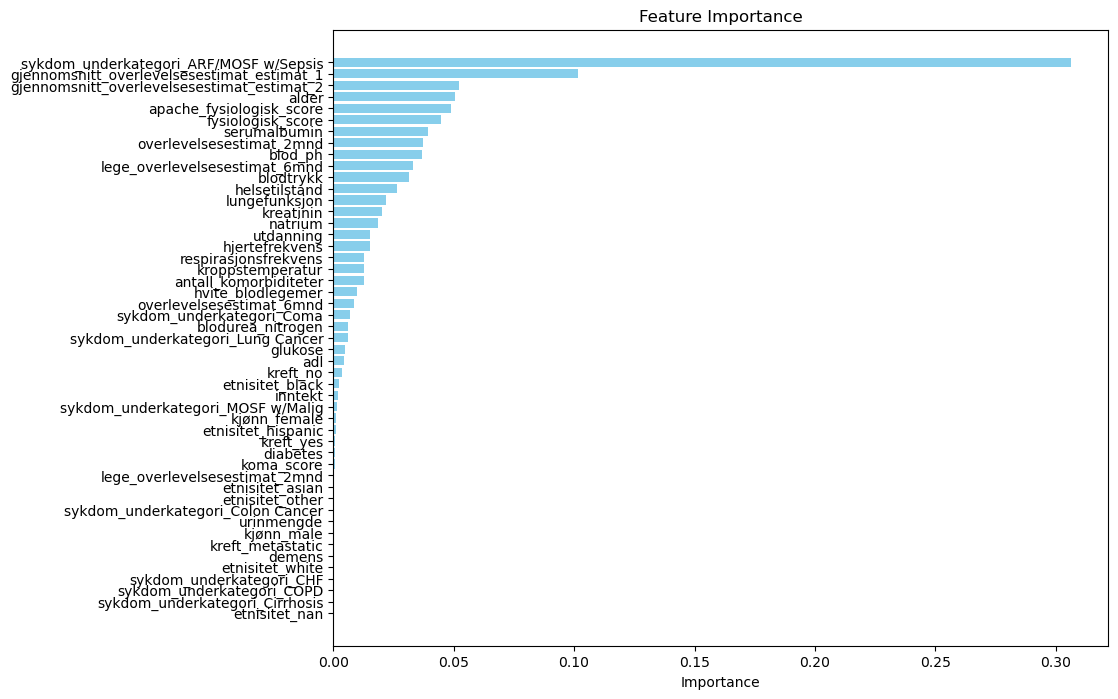

                                       Feature  Importance
31                               etnisitet_nan    0.000000
13              sykdom_underkategori_Cirrhosis    0.000000
12                   sykdom_underkategori_COPD    0.000000
11                    sykdom_underkategori_CHF    0.000000
30                             etnisitet_white    0.000000
7                                       demens    0.000000
18                            kreft_metastatic    0.000000
25                                  kjønn_male    0.000000
44                                  urinmengde    0.000000
14           sykdom_underkategori_Colon Cancer    0.000000
29                             etnisitet_other    0.000000
26                             etnisitet_asian    0.000000
8                lege_overlevelsesestimat_2mnd    0.000352
1                                   koma_score    0.000746
6                                     diabetes    0.000758
20                                   kreft_yes    0.0008

In [773]:
importances = best_model.feature_importances_

# Kombiner med kolonnenavnene
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

# Sorter etter viktighet
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


# Anta at `feature_importance_df` er DataFrame med kolonnene 'Feature' og 'Importance'
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()


print(feature_importance_df)


In [774]:
from sklearn.metrics import root_mean_squared_error


low_importance_features = feature_importance_df[feature_importance_df['Importance'] <= 0.02]['Feature'].tolist()

print("Funksjoner med lav verdi for modellen:", low_importance_features)
print("Antall funksjoner med lav importance:", len(low_importance_features))

X_train_reduced = X_train.drop(columns=low_importance_features)
X_val_reduced = X_val.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)

best_imputer = imputation_strategies[best_strategy_name]
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_reduced), columns=X_train_reduced.columns)
X_val_imputed = pd.DataFrame(imputer.transform(X_val_reduced), columns=X_val_reduced.columns)


best_model.fit(X_train_imputed, y_train)


y_val_pred = best_model.predict(X_val_imputed)
rmse_val = root_mean_squared_error(y_val, y_val_pred)

print(f"RMSE på Valideringssett med Reduserte Funksjoner: {rmse_val:.4f}")


Funksjoner med lav verdi for modellen: ['etnisitet_nan', 'sykdom_underkategori_Cirrhosis', 'sykdom_underkategori_COPD', 'sykdom_underkategori_CHF', 'etnisitet_white', 'demens', 'kreft_metastatic', 'kjønn_male', 'urinmengde', 'sykdom_underkategori_Colon Cancer', 'etnisitet_other', 'etnisitet_asian', 'lege_overlevelsesestimat_2mnd', 'koma_score', 'diabetes', 'kreft_yes', 'etnisitet_hispanic', 'kjønn_female', 'sykdom_underkategori_MOSF w/Malig', 'inntekt', 'etnisitet_black', 'kreft_no', 'adl', 'glukose', 'sykdom_underkategori_Lung Cancer', 'blodurea_nitrogen', 'sykdom_underkategori_Coma', 'overlevelsesestimat_6mnd', 'hvite_blodlegemer', 'antall_komorbiditeter', 'kroppstemperatur', 'respirasjonsfrekvens', 'hjertefrekvens', 'utdanning', 'natrium']
Antall funksjoner med lav importance: 35
RMSE på Valideringssett med Reduserte Funksjoner: 17.3421


Oppdaterer X-Val og X-train med det jeg har gjort tidligere, for å kunne teste modellen på test settet. 

Ser at modellen blir bedre når vi fjerner de minst viktige variablene, da tar jeg vekk disse fra settene

In [775]:
imputer = best_imputer
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_reduced), columns=X_train_reduced.columns)
X_val_imputed = pd.DataFrame(imputer.transform(X_val_reduced), columns=X_val_reduced.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_reduced), columns=X_test_reduced.columns)

# Tren modellen på treningssettet
best_model.fit(X_train_imputed, y_train)

# Beregn RMSE på valideringssettet
y_val_pred = best_model.predict(X_val_imputed)
rmse_val = root_mean_squared_error(y_val, y_val_pred)
print(f"RMSE på Valideringssett: {rmse_val:.4f}")

# Beregn RMSE på testsettet
y_test_pred = best_model.predict(X_test_imputed)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
print(f"RMSE på Testsett: {rmse_test:.4f}")

RMSE på Valideringssett: 17.3421
RMSE på Testsett: 23.8262


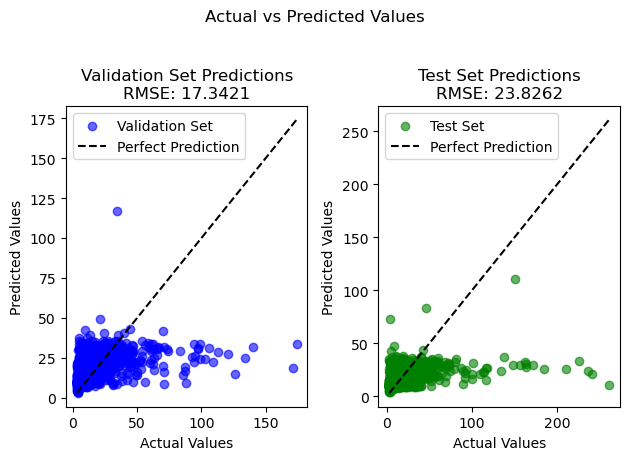

In [776]:


# Valideringssett
plt.subplot(1, 2, 1)
plt.scatter(y_val, y_val_pred, color='blue', alpha=0.6, label='Validation Set')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Validation Set Predictions\nRMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}')
plt.legend()

# Testsett
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.6, label='Test Set')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Set Predictions\nRMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}')
plt.legend()

plt.suptitle('Actual vs Predicted Values')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.show()

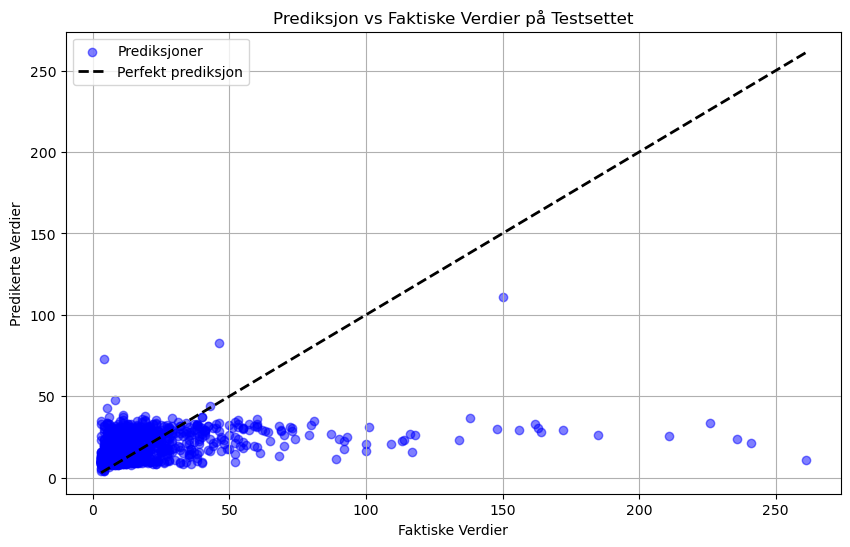

In [777]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue', label='Prediksjoner')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfekt prediksjon')
plt.xlabel('Faktiske Verdier')
plt.ylabel('Predikerte Verdier')
plt.title('Prediksjon vs Faktiske Verdier på Testsettet')
plt.legend()
plt.grid(True)
plt.show()

## Fjerner mindre viktige variabler

## Nettside

In [778]:
print(best_model)

pickle.dump(best_model, open('best_model.pkl', 'wb'))
model = pickle.load(open('best_model.pkl', 'rb'))

X_train_imputed.head()


GradientBoostingRegressor(n_estimators=50, random_state=42)


,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdom_underkategori_ARF/MOSF w/Sepsis,alder,blodtrykk,lungefunksjon,serumalbumin,kreatinin,blod_ph,gjennomsnitt_overlevelsesestimat_estimat_1,gjennomsnitt_overlevelsesestimat_estimat_2,helsetilstand
0,21.097656,37.0,0.619995,0.85,0.0,77.91394,133.0,186.65625,3.299805,0.699951,7.399414,0.682446,0.734998,189.878906
1,33.093750,62.0,0.161987,0.00,0.0,63.10199,97.0,238.09375,3.099609,2.500000,7.289062,0.046000,0.080994,3110.812500
2,28.500000,32.0,0.503906,0.90,0.0,66.98199,41.0,137.00000,3.500000,2.599609,6.929688,0.601489,0.701953,1168.500000
3,13.798828,36.0,0.910889,0.80,0.0,66.59296,76.0,533.25000,3.699707,1.599854,7.479492,0.899988,0.855444,0.000000
4,21.699219,39.0,0.730957,0.90,0.0,74.36798,57.0,412.00000,2.799805,1.699951,7.339844,0.798975,0.815479,0.000000
